<a href="https://colab.research.google.com/github/JSJeong-me/Hair/blob/main/DeepFashion_Virtual_Try_On.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepFashion Try-On

Towards Photo-Realistic Virtual Try-On by Adaptively Generating↔Preserving Image Content, CVPR'20.

![](https://github.com/switchablenorms/DeepFashion_Try_On/raw/master/images/tryon.png)

## For inferencing ACGPN!

ACGPN repo: https://github.com/switchablenorms/DeepFashion_Try_On

This notebook is hard coded for inferencing one image at a time.

Notebook by [Levin Dabhi](https://levindabhi.github.io/)

```
author = {Yang, Han and Zhang, Ruimao and Guo, Xiaobao and Liu, Wei and Zuo, Wangmeng and Luo, Ping},
title = {Towards Photo-Realistic Virtual Try-On by Adaptively Generating-Preserving Image Content},
booktitle = {IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)},
month = {June},
year = {2020}
}

@inproceedings{ge2021disentangled,
  title={Disentangled Cycle Consistency for Highly-realistic Virtual Try-On},
  author={Ge, Chongjian and Song, Yibing and Ge, Yuying and Yang, Han and Liu, Wei and Luo, Ping},
  booktitle={Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition},
  pages={16928--16937},
  year={2021}
}

@inproceedings{yang2022full,
title = {Full-Range Virtual Try-On With Recurrent Tri-Level Transform},
author = {Yang, Han and Yu, Xinrui and Liu, Ziwei},
booktitle = {Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition},
pages = {3460--3469}
year = {2022}
}
```

## ACGPN

- Original: https://github.com/levindabhi/ACGPN.git
- Modified: https://github.com/kairess/ACGPN.git

In [ ]:
!git clone https://github.com/kairess/ACGPN.git
%cd ACGPN

## Dependencies

In [3]:
!pip install -U --no-cache-dir gdown --pre -qq
!pip install ninja -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 kB 4.3 MB/s eta 0:00:00


In [4]:
import gdown
import numpy as np
from PIL import Image
import IPython
import gdown
import os
import sys
import time

from predict_pose import generate_pose_keypoints

In [5]:
!mkdir Data_preprocessing/test_color
!mkdir Data_preprocessing/test_colormask
!mkdir Data_preprocessing/test_edge
!mkdir Data_preprocessing/test_img
!mkdir Data_preprocessing/test_label
!mkdir Data_preprocessing/test_mask
!mkdir Data_preprocessing/test_pose
!mkdir inputs
!mkdir inputs/img
!mkdir inputs/cloth

In [6]:
!git clone https://github.com/levindabhi/Self-Correction-Human-Parsing-for-ACGPN.git
!git clone https://github.com/levindabhi/U-2-Net.git

Cloning into 'Self-Correction-Human-Parsing-for-ACGPN'...
remote: Enumerating objects: 769, done.
remote: Counting objects: 100% (769/769), done.
remote: Compressing objects: 100% (583/583), done.
remote: Total 769 (delta 184), reused 661 (delta 175), pack-reused 0
Receiving objects: 100% (769/769), 3.89 MiB | 4.71 MiB/s, done.
Resolving deltas: 100% (184/184), done.
Cloning into 'U-2-Net'...
remote: Enumerating objects: 822, done.
remote: Counting objects: 100% (327/327), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 822 (delta 308), reused 298 (delta 298), pack-reused 495
Receiving objects: 100% (822/822), 30.71 MiB | 5.80 MiB/s, done.
Resolving deltas: 100% (389/389), done.


## 사전학습 모델 다운로드

### 포즈 예측 모델

In [10]:
# !gdown https://drive.google.com/file/d/1db1haL5GCpbYzvdPGKvfIaWqxDcq-BqY/view?usp=drive_link -O pose/pose_iter_440000.caffemodel

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!ls -l /content/drive/MyDrive/pose_iter_440000.caffemodel

-rw------- 1 root root 209274056 Jul 22 07:50 /content/drive/MyDrive/pose_iter_440000.caffemodel


In [15]:
!cp /content/drive/MyDrive/pose_iter_440000.caffemodel ./pose

### 휴먼 세그멘테이션 마스크 생성 모델

In [17]:
gdown.download('https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH', 'lip_final.pth', quiet=False)

Downloading...
From (uriginal): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH
From (redirected): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH&confirm=t&uuid=26808299-1001-4660-bbf3-f1af774e6b9a
To: /content/ACGPN/lip_final.pth
100%|██████████| 267M/267M [00:04<00:00, 66.2MB/s]


'lip_final.pth'

### U2Net 모델

옷 마스크 추출 모델

In [18]:
%cd U-2-Net
!mkdir saved_models
!mkdir saved_models/u2net
!mkdir saved_models/u2netp

!gdown 1rbSTGKAE-MTxBYHd-51l2hMOQPT_7EPy -O saved_models/u2netp/u2netp.pth
!gdown 1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ -O saved_models/u2net/u2net.pth

import u2net_load
import u2net_run

u2net = u2net_load.model(model_name='u2netp')

%cd ..

/content/ACGPN/U-2-Net
mkdir: cannot create directory ‘saved_models’: File exists
Downloading...
From: https://drive.google.com/uc?id=1rbSTGKAE-MTxBYHd-51l2hMOQPT_7EPy
To: /content/ACGPN/U-2-Net/saved_models/u2netp/u2netp.pth
100% 4.68M/4.68M [00:00<00:00, 21.4MB/s]
Downloading...
From (uriginal): https://drive.google.com/uc?id=1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ
From (redirected): https://drive.google.com/uc?id=1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ&confirm=t&uuid=6fe58a9a-08f8-465e-827c-5ba23ee4c4a5
To: /content/ACGPN/U-2-Net/saved_models/u2net/u2net.pth
100% 176M/176M [00:03<00:00, 45.7MB/s]
...load U2NEP---4.7 MB
/content/ACGPN


### ACGPN 모델

In [19]:
!mkdir checkpoints

gdown.download('https://drive.google.com/uc?id=1UWT6esQIU_d4tUm8cjxDKMhB8joQbrFx', output='checkpoints/ACGPN_checkpoints.zip', quiet=False)

!unzip checkpoints/ACGPN_checkpoints.zip -d checkpoints

Downloading...
From (uriginal): https://drive.google.com/uc?id=1UWT6esQIU_d4tUm8cjxDKMhB8joQbrFx
From (redirected): https://drive.google.com/uc?id=1UWT6esQIU_d4tUm8cjxDKMhB8joQbrFx&confirm=t&uuid=a29523bf-0a8c-4013-90a7-332c21d1ebc5
To: /content/ACGPN/checkpoints/ACGPN_checkpoints.zip
100%|██████████| 524M/524M [00:10<00:00, 49.8MB/s]


Archive:  checkpoints/ACGPN_checkpoints.zip
   creating: checkpoints/label2city/
  inflating: checkpoints/label2city/latest_net_G.pth  
  inflating: checkpoints/label2city/latest_net_G1.pth  
  inflating: checkpoints/label2city/latest_net_G2.pth  
  inflating: checkpoints/label2city/latest_net_U.pth  
  inflating: checkpoints/label2city/opt.txt  


## VITON 데이터셋

https://drive.google.com/uc?id=1tE7hcVFm8Td8kRh5iYRBSDFdvZIkbUIR

## AI허브 패션 데이터셋

https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=78

![](https://aihub.or.kr/web-nas/aihub21/files/public/inline-images/65_%ED%8C%A8%EC%85%98%EC%83%81%ED%92%88%EB%B0%8F%EC%B0%A9%EC%9A%A9%EC%98%81%EC%83%81_%EB%8C%80%ED%91%9C%EB%8F%84.PNG)

## 전처리

### 옷 마스크 추출

In [20]:
sorted(os.listdir('inputs/cloth'))

['000129_1.jpg']

Generating mask for: cloth_1690013771.png
Saving output at Data_preprocessing/test_edge/cloth_1690013771.png


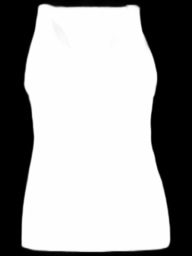

In [21]:
cloth_name = f'cloth_{int(time.time())}.png'

cloth_path = os.path.join('inputs/cloth', sorted(os.listdir('inputs/cloth'))[0])
cloth = Image.open(cloth_path)
cloth = cloth.resize((192, 256), Image.BICUBIC).convert('RGB')
cloth.save(os.path.join('Data_preprocessing/test_color', cloth_name))

u2net_run.infer(u2net, 'Data_preprocessing/test_color', 'Data_preprocessing/test_edge')

Image.open(f'Data_preprocessing/test_edge/{cloth_name}')

### 모델 포즈, 세그멘테이션

In [22]:
sorted(os.listdir('inputs/img'))

['000143_0.jpg']

In [23]:
img_name = f'img_{int(time.time())}.png'

img_path = os.path.join('inputs/img', sorted(os.listdir('inputs/img'))[0])
img = Image.open(img_path)
img = img.resize((192,256), Image.BICUBIC)

img_path = os.path.join('Data_preprocessing/test_img', img_name)
img.save(img_path)

!python3 Self-Correction-Human-Parsing-for-ACGPN/simple_extractor.py --dataset 'lip' --model-restore 'lip_final.pth' --input-dir 'Data_preprocessing/test_img' --output-dir 'Data_preprocessing/test_label'

pose_path = os.path.join('Data_preprocessing/test_pose', img_name.replace('.png', '_keypoints.json'))
generate_pose_keypoints(img_path, pose_path)

100% 1/1 [00:00<00:00,  1.80it/s]
File saved at Data_preprocessing/test_pose/img_1690013791_keypoints.json


## 추론

In [24]:
!rm -rf Data_preprocessing/test_pairs.txt
with open('Data_preprocessing/test_pairs.txt', 'w') as f:
    f.write(f'{img_name} {cloth_name}')

In [25]:
!python test.py

?
------------ Options -------------
aspect_ratio: 1.0
batchSize: 1
checkpoints_dir: ./checkpoints
cluster_path: features_clustered_010.npy
continue_train: False
data_type: 32
datapairs: test_pairs.txt
dataroot: Data_preprocessing/
display_winsize: 512
engine: None
export_onnx: None
fineSize: 512
gpu_ids: [0]
how_many: 1000
input_nc: 3
isTrain: False
label_nc: 20
loadSize: 512
max_dataset_size: inf
model: pix2pixHD
nThreads: 1
n_blocks_global: 4
n_blocks_local: 3
n_downsample_global: 4
n_local_enhancers: 1
name: label2city
netG: global
ngf: 64
niter_fix_global: 0
no_flip: False
norm: instance
ntest: inf
onnx: None
output_nc: 3
phase: test
resize_or_crop: scale_width
results_dir: ./results/
serial_batches: True
tf_log: False
use_dropout: False
use_encoded_image: False
verbose: False
which_epoch: latest
-------------- End ----------------
CustomDatasetDataLoader
dataset [AlignedDataset] was created
Data_preprocessing/test_label label
Data_preprocessing/test_img img
Data_preprocessing/tes

## 결과

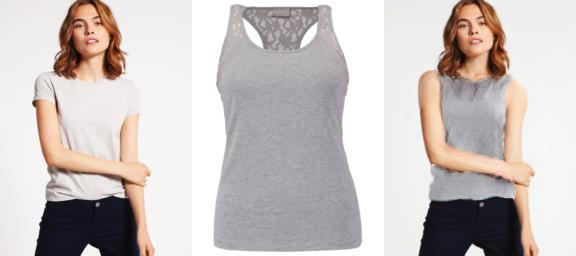

In [26]:
output_grid = np.concatenate([
    np.array(Image.open(f'Data_preprocessing/test_img/{img_name}')),
    np.array(Image.open(f'Data_preprocessing/test_color/{cloth_name}')),
    np.array(Image.open(f'results/test/try-on/{img_name}'))
], axis=1)

image_grid = Image.fromarray(output_grid)

image_grid